# Assignment 6: Applying AI-Based Style Transfer to an Image

**Name:** Keerthi  
**Registration No.:** 2411021240024  
**Course:** BCA (Artificial Intelligence & Machine Learning) — BCA AIML  
**Subject:** Generative AI  
**Topic:** Applying AI-Based Style Transfer to an Image

## 1. Introduction

AI-based image style transfer is a deep learning technique used to transform the visual appearance of an image while preserving important information from the original image.

In this assignment, two different approaches are implemented:

- CycleGAN: A Generative Adversarial Network used for image-to-image translation.
- Neural Style Transfer: A VGG19-based technique that combines the content of one image with the visual style of another image.

The results produced by both methods are compared based on content preservation and style transformation.

## 2. Objective

The objectives of this assignment are:

- To understand AI-based image style transfer.
- To apply a pretrained CycleGAN model to an image.
- To understand the concept of cycle consistency in CycleGAN.
- To apply Neural Style Transfer using a pretrained VGG19 model.
- To preserve the content of the original image while changing its visual appearance.
- To compare the outputs produced by CycleGAN and Neural Style Transfer.

## 3. Upload the Input Images

Two images are required for this assignment:

1. Content Image: A landscape photograph that will be transformed using both methods.
2. Style Image: A painting whose artistic style will be applied using Neural Style Transfer.

The same landscape image is used as the input for both CycleGAN and Neural Style Transfer.

In [ ]:
from google.colab import files

print("Please upload TWO images:")
print("1. Landscape photograph")
print("2. Painting/style image")

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print(filename)

Please upload TWO images:
1. Landscape photograph
2. Painting/style image


Saving Painting image.jpg to Painting image.jpg
Saving Landscape image.jpg to Landscape image.jpg

Uploaded files:
Painting image.jpg
Landscape image.jpg


## 4. Identify the Input Images

The uploaded images are checked and assigned automatically.

The first uploaded image is treated as the content image.
The second uploaded image is treated as the style image.

In [ ]:
from PIL import Image
import os

uploaded_files = list(uploaded.keys())

print("Number of uploaded images:", len(uploaded_files))

if len(uploaded_files) != 2:
    raise ValueError("Please upload exactly TWO images and run the upload cell again.")

content_original = uploaded_files[0]
style_original = uploaded_files[1]

print("Content image:", content_original)
print("Style image:", style_original)

Number of uploaded images: 2
Content image: Painting image.jpg
Style image: Landscape image.jpg


## 5. Prepare the Images

The two uploaded images are copied into standard filenames.

- landscape.jpg → Content image
- style.jpg → Style image

Using standard filenames helps prevent file path errors in later cells.

In [ ]:
import shutil
import os

shutil.copy(
    "/content/" + content_original,
    "/content/landscape.jpg"
)

shutil.copy(
    "/content/" + style_original,
    "/content/style.jpg"
)

print("Images prepared successfully!")
print("Content image: /content/landscape.jpg")
print("Style image: /content/style.jpg")

Images prepared successfully!
Content image: /content/landscape.jpg
Style image: /content/style.jpg


## 6. Verify the Input Files

Before starting the style transfer process, both input images are checked to make sure they are available in Google Colab.

In [ ]:
import os

print("landscape.jpg exists:",
      os.path.exists("/content/landscape.jpg"))

print("style.jpg exists:",
      os.path.exists("/content/style.jpg"))

landscape.jpg exists: True
style.jpg exists: True


## 7. Display the Input Images

The original landscape photograph is used as the content image.

The painting is used as the style reference for Neural Style Transfer.

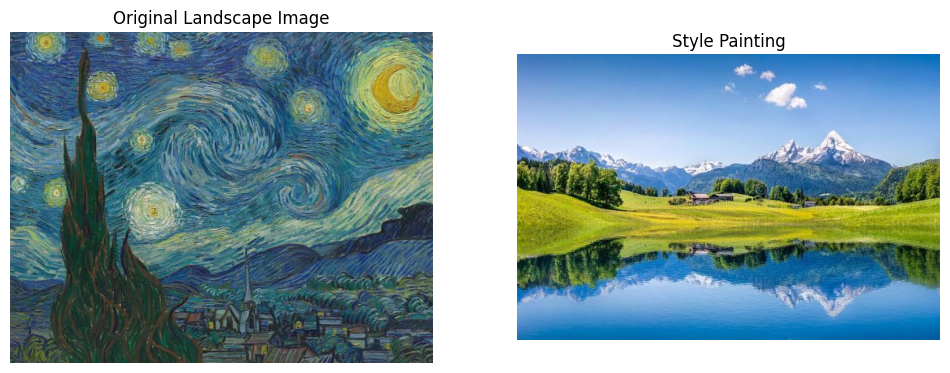

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

content_image = Image.open("/content/landscape.jpg").convert("RGB")
style_image = Image.open("/content/style.jpg").convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(content_image)
plt.title("Original Landscape Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(style_image)
plt.title("Style Painting")
plt.axis("off")

plt.show()

## 8. Method 1: CycleGAN

CycleGAN is a Generative Adversarial Network designed for image-to-image translation.

Unlike traditional image translation methods, CycleGAN does not require paired images.

In this assignment, a pretrained CycleGAN model is used to transform the original landscape photograph into a Monet-like artistic style.

The pretrained model is used directly, so no additional training is required.

### Cycle Consistency

Cycle consistency is an important concept in CycleGAN.

If an image is translated from one domain to another and then translated back to the original domain, the reconstructed image should remain similar to the original image.

For example:

Original Photograph → Artistic Domain → Reconstructed Photograph

This cycle consistency helps CycleGAN perform image translation while preserving important information from the original image.

In [ ]:
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix.git

Cloning into 'pytorch-CycleGAN-and-pix2pix'...
remote: Enumerating objects: 2619, done.
remote: Total 2619 (delta 0), reused 0 (delta 0), pack-reused 2619 (from 1)
Receiving objects: 100% (2619/2619), 8.24 MiB | 10.32 MiB/s, done.
Resolving deltas: 100% (1654/1654), done.


In [ ]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!pip install -q dominate visdom

/content/pytorch-CycleGAN-and-pix2pix
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 37.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 96.9 MB/s eta 0:00:00


## 9. Download the Pretrained CycleGAN Model

A pretrained CycleGAN model is used instead of training a new model from scratch.

The style_monet model is trained to translate photographs into a Monet-like artistic style.

This makes the process faster and suitable for this assignment.

In [ ]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!bash ./scripts/download_cyclegan_model.sh style_monet

/content/pytorch-CycleGAN-and-pix2pix
Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 14:44:00--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  13.3MB/s    in 3.3s    

2026-10-03 14:44:04 (13.3 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pt

## 10. Prepare the Dataset for CycleGAN

CycleGAN expects input images to be placed inside a specific dataset folder.

The original landscape image is copied into the test folder.

This image will be used as the input for the pretrained style_monet model.

In [ ]:
%cd /content/pytorch-CycleGAN-and-pix2pix

import os
import shutil

os.makedirs("datasets/my_landscape/testA", exist_ok=True)

shutil.copy(
    "/content/landscape.jpg",
    "datasets/my_landscape/testA/landscape.jpg"
)

print("Landscape image copied successfully!")
print("/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA/landscape.jpg")

/content/pytorch-CycleGAN-and-pix2pix
Landscape image copied successfully!
/content/pytorch-CycleGAN-and-pix2pix/datasets/my_landscape/testA/landscape.jpg


## 11. Apply CycleGAN Style Transfer

The pretrained CycleGAN model is applied to the original landscape image.

The model translates the photograph into a Monet-like artistic style while attempting to preserve the main structure and content of the original scene.

No additional model training is performed.

In [ ]:
%cd /content/pytorch-CycleGAN-and-pix2pix

!python test.py \
    --dataroot ./datasets/my_landscape \
    --name style_monet_pretrained \
    --model test \
    --no_dropout \
    --preprocess resize

/content/pytorch-CycleGAN-and-pix2pix
----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: ./datasets/my_landscape       	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
     

## 12. CycleGAN Output

The pretrained CycleGAN model has transformed the original landscape photograph into a Monet-like artistic style.

The generated image is displayed below and will later be compared with the Neural Style Transfer result.

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os

output_folder = "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images"

print("Files generated by CycleGAN:")

for file in os.listdir(output_folder):
    print(file)

Files generated by CycleGAN:
landscape_fake.png
landscape_real.png


## 13. Visualizing the CycleGAN Result

The generated CycleGAN image is displayed alongside the original landscape image.

The landscape_fake.png image represents the output produced by the pretrained CycleGAN model.

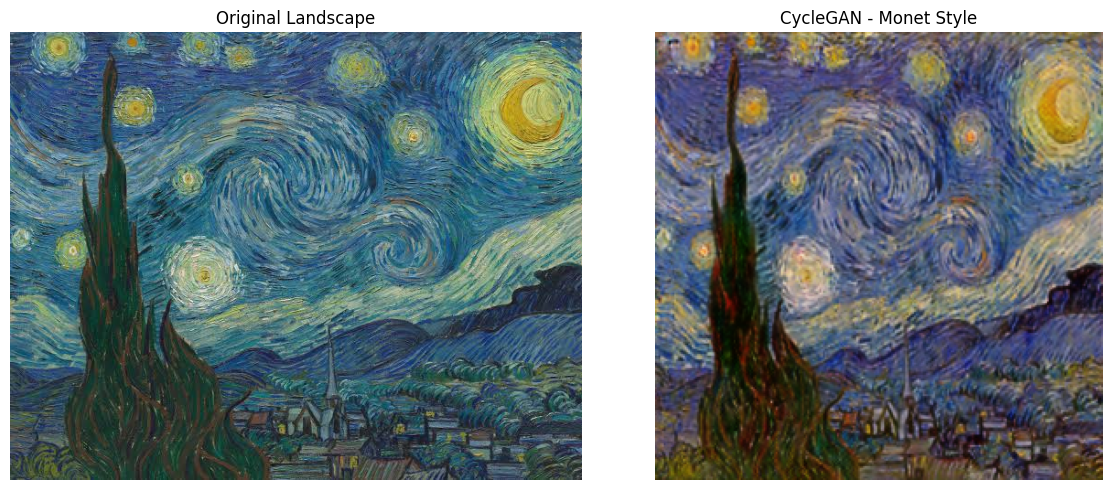

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open("/content/landscape.jpg").convert("RGB")

cyclegan_output = Image.open(
    "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png"
).convert("RGB")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Landscape")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN - Monet Style")
plt.axis("off")

plt.tight_layout()
plt.show()

## 14. Method 2: Neural Style Transfer

Neural Style Transfer is a deep learning technique that combines the content of one image with the artistic style of another image.

In this assignment:

- The landscape image provides the content.
- The painting provides the artistic style.
- A pretrained VGG19 network is used to extract content and style features.

The goal is to preserve the important structure of the landscape while applying the visual characteristics of the painting.

In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


## 15. Load the Pretrained VGG19 Network

VGG19 is a pretrained convolutional neural network commonly used for Neural Style Transfer.

Different layers of VGG19 capture different types of information:

- Earlier layers capture simple features such as edges and textures.
- Deeper layers capture more complex shapes and content.

The network is used for feature extraction and its weights are not modified.

In [ ]:
import torch
import torchvision.models as models

vgg = models.vgg19(
    weights=models.VGG19_Weights.DEFAULT
).features.to(device)

vgg.eval()

for param in vgg.parameters():
    param.requires_grad = False

print("VGG19 loaded successfully!")
print("Using device:", device)

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:03<00:00, 144MB/s]


VGG19 loaded successfully!
Using device: cuda


## 16. Load and Preprocess the Images

The same landscape image used for CycleGAN is used as the content image.

The painting is used as the style image.

Both images are resized to 512 × 512 pixels and converted into PyTorch tensors so that they can be processed by the VGG19 network.

In [ ]:
from PIL import Image
import torchvision.transforms as transforms

image_size = 512

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

content_image = Image.open(
    "/content/landscape.jpg"
).convert("RGB")

style_image = Image.open(
    "/content/style.jpg"
).convert("RGB")

content = transform(content_image).unsqueeze(0).to(device)
style = transform(style_image).unsqueeze(0).to(device)

print("Content image tensor shape:", content.shape)
print("Style image tensor shape:", style.shape)

Content image tensor shape: torch.Size([1, 3, 512, 512])
Style image tensor shape: torch.Size([1, 3, 512, 512])


## 17. Select Content and Style Layers

For Neural Style Transfer, different VGG19 layers are used to extract different types of features.

A deeper layer is selected to capture the main structure and content of the landscape.

Multiple layers are selected to capture artistic features such as colors, textures, edges, and patterns.

In [ ]:
content_layers = ['21']

style_layers = ['0', '5', '10', '19', '28']

print("Content layer:", content_layers)
print("Style layers:", style_layers)

Content layer: ['21']
Style layers: ['0', '5', '10', '19', '28']


## 18. Extract Content and Style Features

The pretrained VGG19 network is used to extract features from the content and style images.

- Content features contain information about the structure and objects in the landscape.
- Style features contain information about colors, textures, patterns, and artistic appearance.

In [ ]:
def get_features(image, model, layers):
    features = {}

    x = image

    for name, layer in model._modules.items():
        x = layer(x)

        if name in layers:
            features[name] = x

    return features


content_features = get_features(
    content,
    vgg,
    content_layers
)

style_features = get_features(
    style,
    vgg,
    style_layers
)

print("Content features extracted:", list(content_features.keys()))
print("Style features extracted:", list(style_features.keys()))

Content features extracted: ['21']
Style features extracted: ['0', '5', '10', '19', '28']


## 19. Calculate the Gram Matrix

The Gram Matrix is used in Neural Style Transfer to represent the style of an image.

It captures relationships between different feature maps produced by the VGG19 network.

The Gram Matrix helps represent visual characteristics such as:

- Texture
- Patterns
- Colors
- Artistic appearance

In [ ]:
def gram_matrix(tensor):

    batch_size, depth, height, width = tensor.size()

    features = tensor.view(
        batch_size * depth,
        height * width
    )

    gram = torch.mm(
        features,
        features.t()
    )

    gram = gram / (
        batch_size * depth * height * width
    )

    return gram


style_grams = {}

for layer in style_layers:
    style_grams[layer] = gram_matrix(
        style_features[layer]
    )

print("Gram matrices calculated successfully!")

for layer in style_grams:
    print(
        "Layer",
        layer,
        ":",
        style_grams[layer].shape
    )

Gram matrices calculated successfully!
Layer 0 : torch.Size([64, 64])
Layer 5 : torch.Size([128, 128])
Layer 10 : torch.Size([256, 256])
Layer 19 : torch.Size([512, 512])
Layer 28 : torch.Size([512, 512])


## 20. Create the Target Image

The target image is initialized as a copy of the original landscape image.

During Neural Style Transfer, this target image is gradually modified.

The optimization process tries to:

- Keep the content similar to the original landscape.
- Make the visual style similar to the selected painting.

The target image becomes the final Neural Style Transfer output.

In [ ]:
target = content.clone().requires_grad_(True)

print("Target image created successfully!")
print("Target shape:", target.shape)

Target image created successfully!
Target shape: torch.Size([1, 3, 512, 512])


## 21. Content Loss and Style Loss

Neural Style Transfer uses two main types of loss.

### Content Loss

Content loss measures how different the generated image is from the original landscape in terms of its important visual structure.

A lower content loss means the generated image preserves the original content more closely.

### Style Loss

Style loss measures how different the generated image is from the painting in terms of texture, colors, and patterns.

A lower style loss means the generated image is visually closer to the selected painting.

The total loss combines both content loss and style loss.

In [22]:
content_weight = 1
style_weight = 1000000

optimizer = torch.optim.Adam(
    [target],
    lr=0.003
)

print("Content weight:", content_weight)
print("Style weight:", style_weight)
print("Optimizer: Adam")

Content weight: 1
Style weight: 1000000
Optimizer: Adam


## 22. Perform Neural Style Transfer

The target image is optimized using the Adam optimizer.

During each iteration:

1. Features are extracted from the target image using VGG19.
2. Content loss is calculated by comparing the target with the original landscape.
3. Style loss is calculated by comparing the Gram Matrices of the target and the painting.
4. The total loss is calculated.
5. The target image is updated to reduce the total loss.

After several iterations, the target image contains the content of the landscape and the visual characteristics of the painting.

In [23]:
num_steps = 500

print("Starting Neural Style Transfer...")
print("Total steps:", num_steps)

for step in range(1, num_steps + 1):

    target_features = get_features(
        target,
        vgg,
        content_layers + style_layers
    )

    content_loss = torch.mean(
        (target_features['21'] -
         content_features['21']) ** 2
    )

    style_loss = 0

    for layer in style_layers:

        target_gram = gram_matrix(
            target_features[layer]
        )

        style_loss += torch.mean(
            (target_gram -
             style_grams[layer]) ** 2
        )

    total_loss = (
        content_weight * content_loss +
        style_weight * style_loss
    )

    optimizer.zero_grad()

    total_loss.backward()

    optimizer.step()

    with torch.no_grad():
        target.clamp_(0, 1)

    if step % 50 == 0:
        print(
            f"Step {step}/{num_steps} | "
            f"Content Loss: {content_loss.item():.4f} | "
            f"Style Loss: {style_loss.item():.4f} | "
            f"Total Loss: {total_loss.item():.4f}"
        )

Starting Neural Style Transfer...
Total steps: 500
Step 50/500 | Content Loss: 0.2878 | Style Loss: 0.0000 | Total Loss: 0.5874
Step 100/500 | Content Loss: 0.2867 | Style Loss: 0.0000 | Total Loss: 0.5798
Step 150/500 | Content Loss: 0.2851 | Style Loss: 0.0000 | Total Loss: 0.5750
Step 200/500 | Content Loss: 0.2852 | Style Loss: 0.0000 | Total Loss: 0.5712
Step 250/500 | Content Loss: 0.2883 | Style Loss: 0.0000 | Total Loss: 0.5683
Step 300/500 | Content Loss: 0.2865 | Style Loss: 0.0000 | Total Loss: 0.5651
Step 350/500 | Content Loss: 0.2837 | Style Loss: 0.0000 | Total Loss: 0.5629
Step 400/500 | Content Loss: 0.2825 | Style Loss: 0.0000 | Total Loss: 0.5610
Step 450/500 | Content Loss: 0.2827 | Style Loss: 0.0000 | Total Loss: 0.5592
Step 500/500 | Content Loss: 0.2845 | Style Loss: 0.0000 | Total Loss: 0.5576


## 23. Neural Style Transfer Output

The optimized target image is now displayed.

The result should preserve the main content and structure of the original landscape while incorporating visual characteristics from the selected painting.

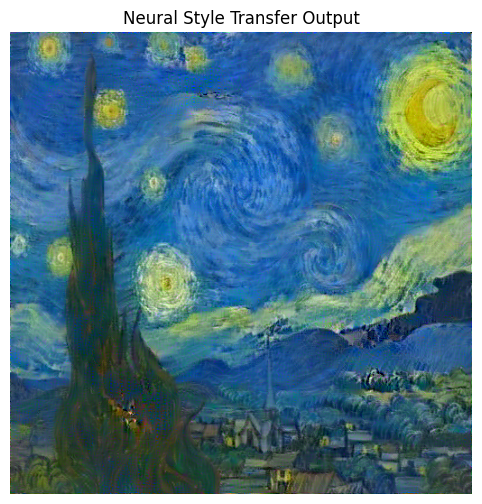

In [24]:
import matplotlib.pyplot as plt

nst_output = (
    target.detach()
    .cpu()
    .squeeze(0)
    .permute(1, 2, 0)
    .numpy()
)

plt.figure(figsize=(8, 6))

plt.imshow(nst_output)

plt.title("Neural Style Transfer Output")

plt.axis("off")

plt.show()

## 24. Save the Neural Style Transfer Output

The generated Neural Style Transfer image is saved as a JPG file so that it can be used in the final comparison.

In [25]:
from PIL import Image

nst_image = Image.fromarray(
    (nst_output * 255)
    .clip(0, 255)
    .astype("uint8")
)

nst_image.save(
    "/content/neural_style_transfer_output.jpg"
)

print("NST output saved successfully!")

print("/content/neural_style_transfer_output.jpg")

NST output saved successfully!
/content/neural_style_transfer_output.jpg


## 25. Comparison of Style Transfer Methods

The original landscape image and the outputs from both style transfer methods are compared side by side.

The three images are:

1. Original Image
2. CycleGAN Output
3. Neural Style Transfer Output

This comparison helps us observe how each method changes the visual appearance while preserving the original content.

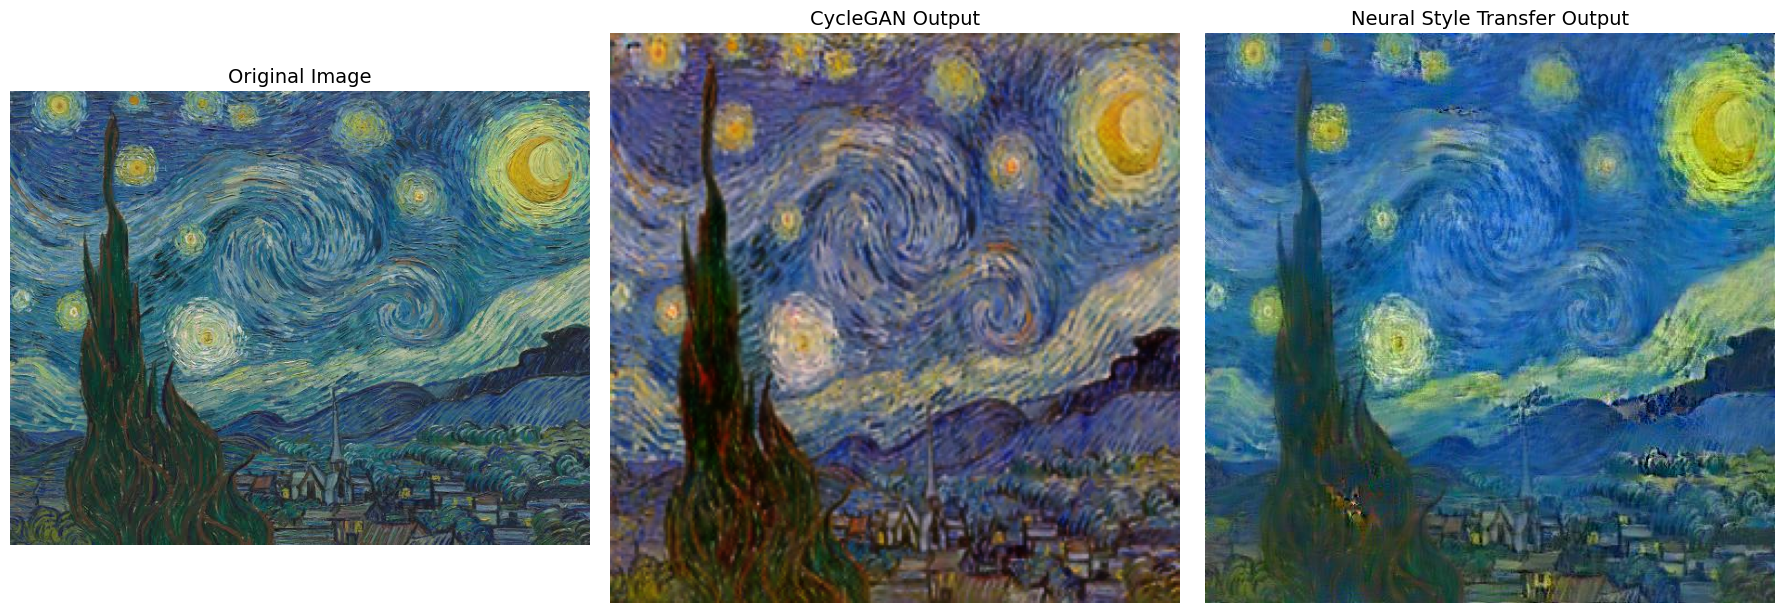

In [26]:
from PIL import Image
import matplotlib.pyplot as plt

original = Image.open(
    "/content/landscape.jpg"
).convert("RGB")

cyclegan_output = Image.open(
    "/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/landscape_fake.png"
).convert("RGB")

nst_output_image = Image.open(
    "/content/neural_style_transfer_output.jpg"
).convert("RGB")


plt.figure(figsize=(18, 6))


plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image", fontsize=14)
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN Output", fontsize=14)
plt.axis("off")


plt.subplot(1, 3, 3)
plt.imshow(nst_output_image)
plt.title("Neural Style Transfer Output", fontsize=14)
plt.axis("off")


plt.tight_layout()
plt.show()

## 26. Save the Final Comparison

The three-image comparison is saved as a single image for inclusion in the assignment report.

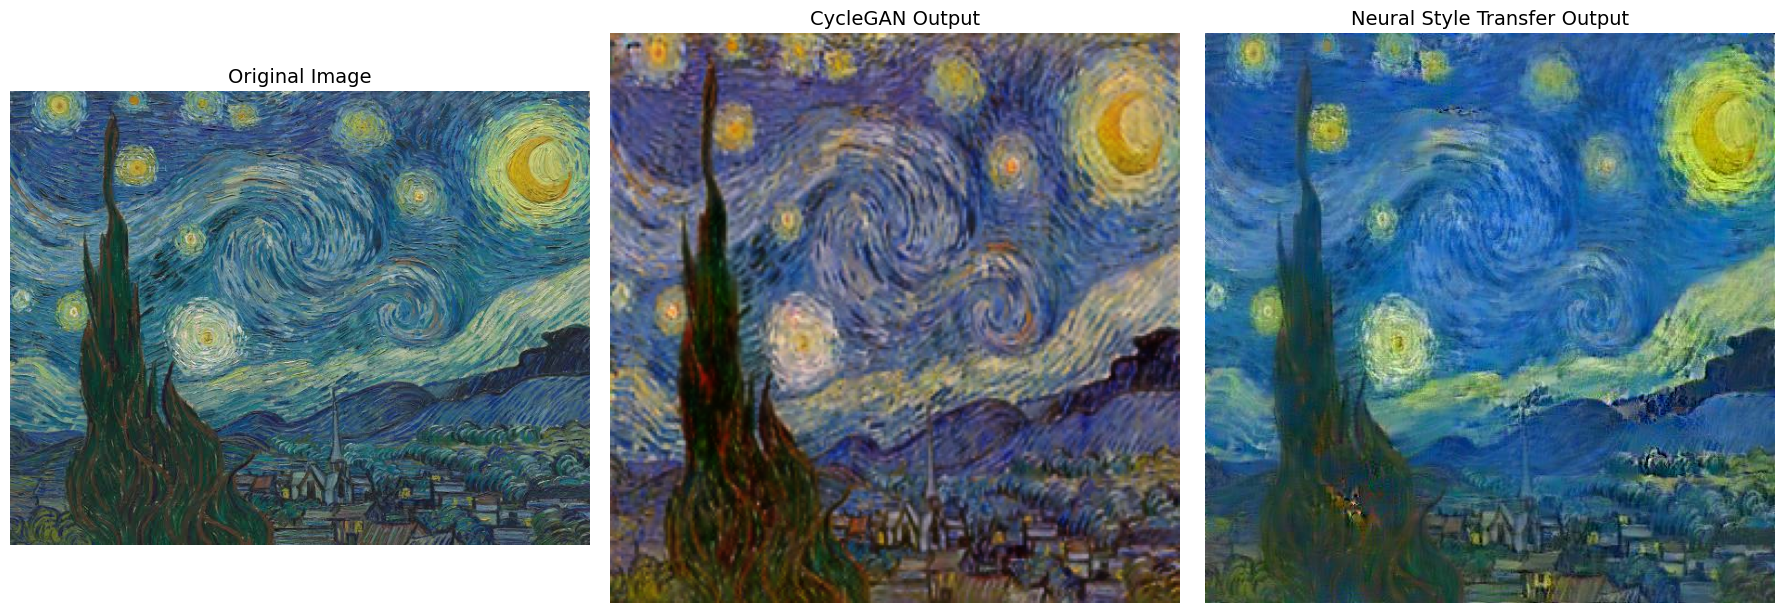

Comparison saved successfully!
/content/Assignment_6_Comparison.png


In [27]:
comparison_path = "/content/Assignment_6_Comparison.png"

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original Image", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cyclegan_output)
plt.title("CycleGAN Output", fontsize=14)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(nst_output_image)
plt.title("Neural Style Transfer Output", fontsize=14)
plt.axis("off")

plt.tight_layout()

plt.savefig(
    comparison_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Comparison saved successfully!")
print(comparison_path)

## 27. Written Comparison

Neural Style Transfer preserved the original content and structure of the landscape more clearly because it directly uses the content features extracted from the original image. CycleGAN produced a stronger overall domain-style transformation and changed the appearance of the photograph into a Monet-like artistic style. Neural Style Transfer produced more visible painting-like textures, colors, and patterns from the selected style image. The main difference is that CycleGAN performs image-to-image domain translation, while Neural Style Transfer combines content and style features using VGG19.

## 28. Comparison of CycleGAN and Neural Style Transfer

| Feature | CycleGAN | Neural Style Transfer |
|---|---|---|
| Main purpose | Image-to-image translation | Artistic style transfer |
| Model used | Pretrained CycleGAN | Pretrained VGG19 |
| Input | Original landscape image | Content image + style painting |
| Style | Monet-like style learned by the model | Style taken from the selected painting |
| Content preservation | Attempts to preserve the main structure | Preserves content using content features |
| Training for this assignment | No additional training | No additional training |
| Main technique | Adversarial learning and cycle consistency | Content loss and style loss |

## 29. Cycle Consistency in CycleGAN

Cycle consistency is an important concept in CycleGAN.

The model learns transformations between two image domains. If an image is translated from the first domain to the second domain and then translated back, the reconstructed image should remain similar to the original image.

For example:

Original Photograph → Artistic Domain → Reconstructed Photograph

This helps the model perform image translation while preserving important information from the original image.

## 30. Conclusion

In this assignment, two AI-based style transfer techniques were applied to the same landscape image.

CycleGAN used a pretrained model to translate the photograph into a Monet-like artistic domain. Neural Style Transfer used VGG19 to combine the content of the landscape with the style of a selected painting.

The experiment demonstrates how different deep learning approaches can generate artistic transformations while retaining important visual information from the original image.

## 31. Final Result

The final comparison consists of three images:

1. Original Image
2. CycleGAN Output
3. Neural Style Transfer Output

These results demonstrate the difference between domain-based image translation using CycleGAN and painting-based artistic style transfer using Neural Style Transfer.